In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Any, Optional

In [ ]:
class State(TypedDict):
    words: List[Dict[str, Any]]
    selected_mode: str
    current_index: int
    current_word: Optional[Dict[str, Any]]
    current_result: Optional[Dict[str, Any]]
    history: List[Dict[str, Any]]

graph_builder = StateGraph(State)

In [ ]:
def load_current_word(state: State):
    words = state["words"]
    idx = state["current_index"]

    if idx >= len(words):
        return {"current_word": None}

    return {"current_word": words[idx]}


def select_mode(state: State):
    # 이미 selected_mode가 state에 있으므로 그대로 통과만 시킴
    return {}


def decide_path(state: State):
    mapping = {
        "quiz": "quiz_node",
        "reading": "reading_node",
        "tracing": "tracing_node",
    }

    mode = state["selected_mode"]

    if mode not in mapping:
        raise ValueError(f"유효하지 않은 학습 방식입니다: {mode}")

    return mapping[mode]


def quiz_node(state: State):
    current_word = state["current_word"]

    if current_word is None:
        return {"current_result": None}

    result = {
        "mode": "quiz",
        "word": current_word["word"],
        "meaning": current_word.get("meaning", ""),
        "question": f'"{current_word["word"]}"의 뜻은 무엇인가요?',
        "user_answer": "예시 사용자 답변",
        "is_correct": True,
        "score": 100,
    }

    return {"current_result": result}


def reading_node(state: State):
    current_word = state["current_word"]

    if current_word is None:
        return {"current_result": None}

    result = {
        "mode": "reading",
        "word": current_word["word"],
        "meaning": current_word.get("meaning", ""),
        "passage": f'{current_word["word"]}를 활용한 예문입니다.',
        "question": f'위 문장에서 "{current_word["word"]}"의 의미로 가장 적절한 것은?',
        "user_answer": "예시 사용자 답변",
        "is_correct": True,
        "score": 90,
    }

    return {"current_result": result}


def tracing_node(state: State):
    current_word = state["current_word"]

    if current_word is None:
        return {"current_result": None}

    result = {
        "mode": "tracing",
        "word": current_word["word"],
        "meaning": current_word.get("meaning", ""),
        "prompt": f'"{current_word["word"]}"를 3번 따라 써보세요.',
        "user_written": f'{current_word["word"]} {current_word["word"]} {current_word["word"]}',
        "completed": True,
        "score": 80,
    }

    return {"current_result": result}


def save_result(state: State):
    current_result = state["current_result"]

    if current_result is None:
        return {}

    history = state.get("history", [])
    new_history = history + [current_result]

    return {"history": new_history}


def move_to_next_word(state: State):
    return {
        "current_index": state["current_index"] + 1,
        "current_word": None,
        "current_result": None,
    }


def should_continue(state: State):
    if state["current_index"] < len(state["words"]):
        return "load_current_word"
    return "end"

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("load_current_word", load_current_word)
graph_builder.add_node("select_mode", select_mode)
graph_builder.add_node("quiz_node", quiz_node)
graph_builder.add_node("reading_node", reading_node)
graph_builder.add_node("tracing_node", tracing_node)
graph_builder.add_node("save_result", save_result)
graph_builder.add_node("move_to_next_word", move_to_next_word)

graph_builder.add_edge(START, "load_current_word")

graph_builder.add_conditional_edges(
    "load_current_word",
    lambda state: "end" if state["current_word"] is None else "select_mode",
    {
        "select_mode": "select_mode",
        "end": END,
    },
)

graph_builder.add_conditional_edges(
    "select_mode",
    decide_path,
    {
        "quiz_node": "quiz_node",
        "reading_node": "reading_node",
        "tracing_node": "tracing_node",
    },
)

graph_builder.add_edge("quiz_node", "save_result")
graph_builder.add_edge("reading_node", "save_result")
graph_builder.add_edge("tracing_node", "save_result")

graph_builder.add_edge("save_result", "move_to_next_word")

graph_builder.add_conditional_edges(
    "move_to_next_word",
    should_continue,
    {
        "load_current_word": "load_current_word",
        "end": END,
    },
)

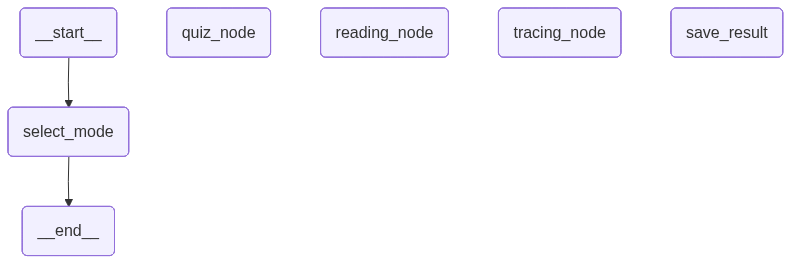

In [27]:
graph = graph_builder.compile()

graph